In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
gwosi = pd.read_excel('Gwosi_2017 NEW.xlsx')
doninga = pd.read_excel('DoningaNASAground.xlsx')

In [31]:
gwosi.PRECTOTCORR.max()

0.0

In [35]:
doninga

,AirTemp,T2M,RH,RH2M,SlrW/avg,SolarRad(NASA),WS,WS2M,Rain/Tot,Rainfall(NASA)
0,24.922857,24.97,27.165505,35.90,202.762794,20.63,1.370509,3.41,0.0,0.0
1,25.253229,24.28,25.762986,37.71,204.396094,20.99,1.547354,2.84,0.0,0.0
2,24.678021,24.53,25.977292,34.54,192.393375,20.76,1.460962,2.23,0.0,0.0
3,24.780035,24.98,28.696111,31.91,210.404531,21.06,1.361552,3.07,0.0,0.0
4,25.372535,25.05,27.207708,33.18,211.877722,20.92,1.302701,3.23,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
360,25.995417,25.95,28.242292,34.13,194.688347,15.73,1.467122,2.27,0.0,0.0
361,26.739896,26.24,29.284236,35.13,196.544444,16.40,1.244330,1.91,0.0,0.0
362,25.636215,26.18,29.799028,32.04,198.364097,18.28,1.313448,2.43,0.0,0.0
363,26.389479,26.13,25.354306,29.14,212.982726,19.99,1.756823,2.60,0.0,0.0


In [6]:
import pandas as pd

# Load data
gwosi = pd.read_excel("Gwosi_2017 NEW.xlsx")

# --- Step 1: Clean TIMESTAMP ---
# Convert TIMESTAMP to datetime (if not already)
gwosi["TIMESTAMP"] = pd.to_datetime(gwosi["TIMESTAMP"], errors="coerce")

# Drop rows with NaN TIMESTAMP
gwosi = gwosi.dropna(subset=["TIMESTAMP"])

# Set TIMESTAMP as index for resampling
gwosi = gwosi.set_index("TIMESTAMP")

# --- Step 2: Resample to daily ---
# Define aggregation rules
agg_rules = {
    "T2M": "mean",
    "WS10M": "mean",
    "RH2M": "mean",
    "PRECTOTCORR": "sum"
}

gwosi_daily = gwosi.resample("D").agg(agg_rules)

# Reset index to keep TIMESTAMP as a column
gwosi_daily = gwosi_daily.reset_index()
gwosi_daily.to_xlsx('Gwosi_daily.xlsx')

print(gwosi_daily.head())
print(gwosi_daily.shape)


   TIMESTAMP    T2M  WS10M   RH2M  PRECTOTCORR
0 2017-01-01  18.83   4.26  60.73          0.0
1 2017-01-02  18.08   4.43  60.82          0.0
2 2017-01-03  17.38   4.53  61.24          0.0
3 2017-01-04  16.79   4.61  62.01          0.0
4 2017-01-05  16.28   4.68  62.72          0.0
(365, 5)


In [12]:
# Save Gwosi daily cleaned dataset
gwosi_daily.to_excel("Gwosi_daily.xlsx", index=False)

# Then reload with openpyxl engine
gwosi_daily = pd.read_excel("Gwosi_daily.xlsx", engine="openpyxl")
doninga = pd.read_excel("DoningaNASAground.xlsx", engine="openpyxl")


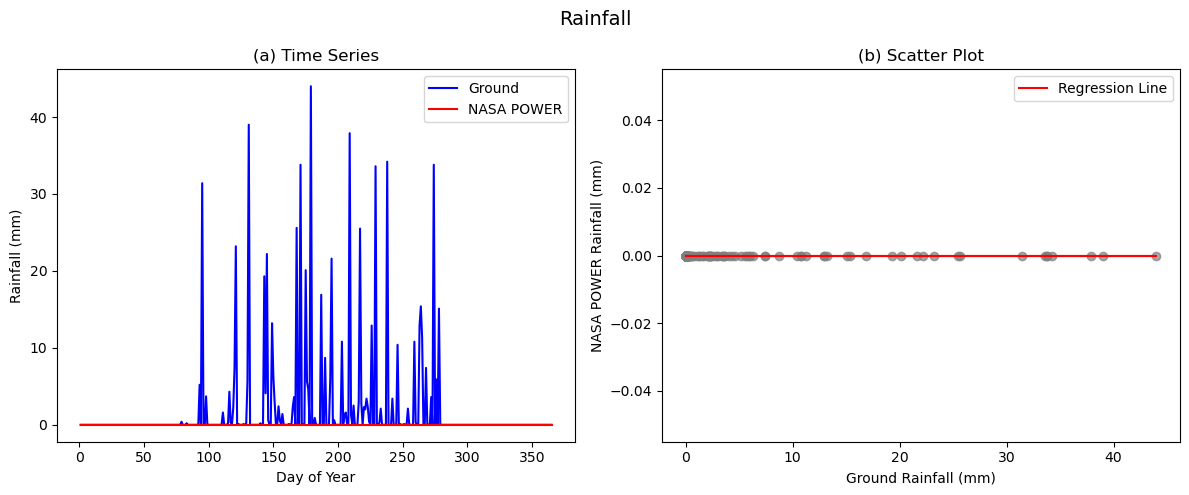

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load datasets
gwosi_daily = pd.read_excel("Gwosi_daily.xlsx", engine="openpyxl")
doninga = pd.read_excel("DoningaNASAground.xlsx", engine="openpyxl")

# --- Align Rainfall columns ---
# Ground (Doninga) vs NASA (Gwosi)
ground_rain = doninga["Rain/Tot"].values
nasa_rain = gwosi_daily["PRECTOTCORR"].values

# Create day-of-year axis
days = np.arange(1, len(ground_rain) + 1)

# --- Regression line for scatter plot ---
X = ground_rain.reshape(-1, 1)
y = nasa_rain
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Time Series
axes[0].plot(days, ground_rain, label="Ground", color="blue")
axes[0].plot(days, nasa_rain, label="NASA POWER", color="red")
axes[0].set_title("(a) Time Series")
axes[0].set_xlabel("Day of Year")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].legend()

# (b) Scatter Plot
axes[1].scatter(ground_rain, nasa_rain, color="gray", alpha=0.7)
axes[1].plot(ground_rain, y_pred, color="red", label="Regression Line")
axes[1].set_title("(b) Scatter Plot")
axes[1].set_xlabel("Ground Rainfall (mm)")
axes[1].set_ylabel("NASA POWER Rainfall (mm)")
axes[1].legend()

plt.suptitle("Rainfall", fontsize=14)
plt.tight_layout()
plt.savefig('rain.png')
plt.show()



In [15]:
print(gwosi_daily[["PRECTOTCORR"]].describe())
print(gwosi_daily.head(15))


       PRECTOTCORR
count        365.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
    TIMESTAMP    T2M  WS10M   RH2M  PRECTOTCORR
0  2017-01-01  18.83   4.26  60.73            0
1  2017-01-02  18.08   4.43  60.82            0
2  2017-01-03  17.38   4.53  61.24            0
3  2017-01-04  16.79   4.61  62.01            0
4  2017-01-05  16.28   4.68  62.72            0
5  2017-01-06  15.83   4.70  63.35            0
6  2017-01-07  15.72   4.74  62.87            0
7  2017-01-08  17.87   5.63  53.65            0
8  2017-01-09  20.76   4.92  47.74            0
9  2017-01-10  24.80   6.35  37.02            0
10 2017-01-11  27.90   7.56  29.69            0
11 2017-01-12  29.98   7.38  26.16            0
12 2017-01-13  31.23   6.61  24.95            0
13 2017-01-14  31.82   5.81  24.61            0
14 2017-01-15  31.84   5.12  24.93            0


In [16]:
print(doninga[["Rain/Tot", "Rainfall(NASA)"]].describe())


         Rain/Tot  Rainfall(NASA)
count  365.000000      365.000000
mean     1.935890        3.071781
std      6.417533        7.912286
min      0.000000        0.000000
25%      0.000000        0.000000
50%      0.000000        0.280000
75%      0.000000        2.960000
max     44.000000      106.260000


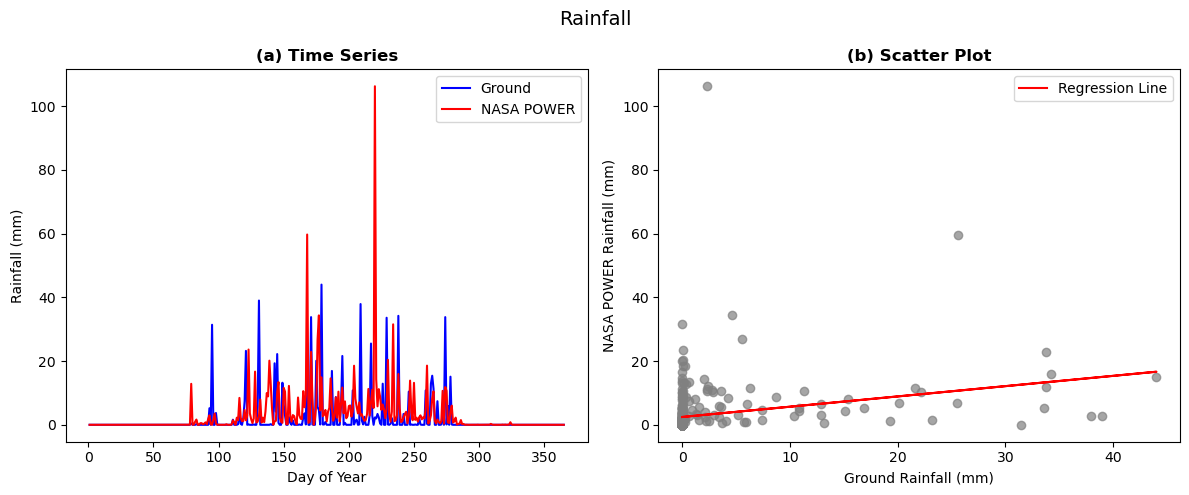

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load Doninga dataset
doninga = pd.read_excel("DoningaNASAground.xlsx", engine="openpyxl")

# Extract rainfall
ground_rain = doninga["Rain/Tot"].values
nasa_rain = doninga["Rainfall(NASA)"].values

# Create day-of-year axis
days = np.arange(1, len(ground_rain) + 1)

# --- Regression line ---
X = ground_rain.reshape(-1, 1)
y = nasa_rain
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Time Series
axes[0].plot(days, ground_rain, label="Ground", color="blue")
axes[0].plot(days, nasa_rain, label="NASA POWER", color="red")
axes[0].set_title("(a) Time Series",fontweight='bold')
axes[0].set_xlabel("Day of Year")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].legend()

# (b) Scatter Plot
axes[1].scatter(ground_rain, nasa_rain, color="gray", alpha=0.7)
axes[1].plot(ground_rain, y_pred, color="red", label="Regression Line")
axes[1].set_title("(b) Scatter Plot",fontweight='bold')
axes[1].set_xlabel("Ground Rainfall (mm)")
axes[1].set_ylabel("NASA POWER Rainfall (mm)")
axes[1].legend()

plt.suptitle("Rainfall", fontsize=14)
plt.tight_layout()
plt.show()


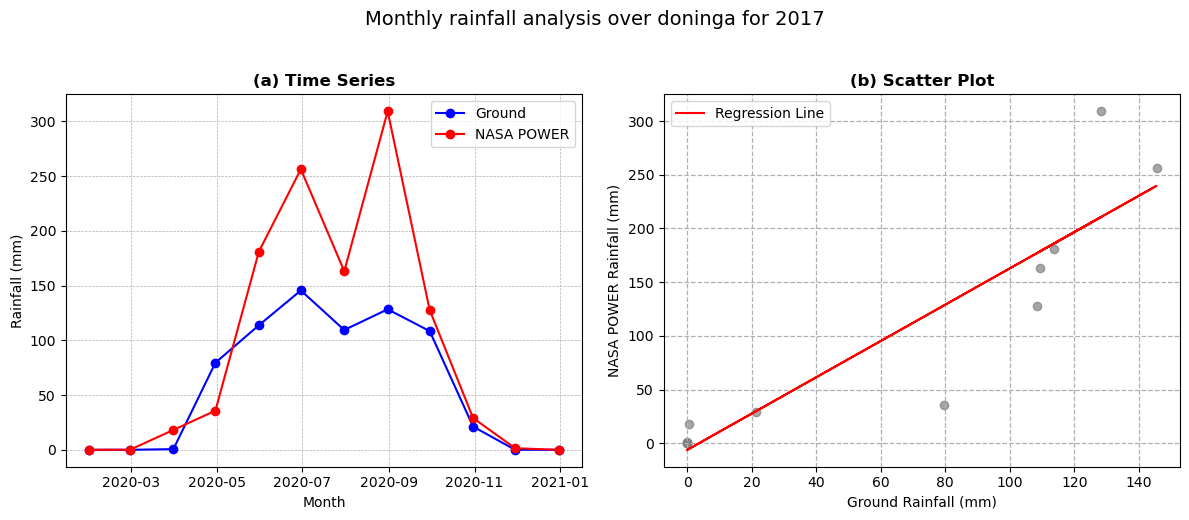

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load Doninga dataset
doninga = pd.read_excel("DoningaNASAground.xlsx", engine="openpyxl")

# Extract rainfall
ground_rain = doninga["Rain/Tot"].values
nasa_rain = doninga["Rainfall(NASA)"].values

# --- Build a datetime index for grouping ---
# Assume year = 2020 (non-leap), adjust if needed
days = pd.date_range("2020-01-01", periods=len(ground_rain), freq="D")
df = pd.DataFrame({
    "Ground": ground_rain,
    "NASA": nasa_rain
}, index=days)

# --- Monthly sums ---
monthly = df.resample("ME").sum()

# --- Regression line (monthly) ---
X = monthly["Ground"].values.reshape(-1, 1)
y = monthly["NASA"].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Monthly Time Series
axes[0].plot(monthly.index, monthly["Ground"], label="Ground", color="blue", marker="o")
axes[0].plot(monthly.index, monthly["NASA"], label="NASA POWER", color="red", marker="o")
axes[0].set_title("(a) Time Series", fontweight='bold')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].grid(True,linewidth=0.5,linestyle='--')
axes[0].legend()

# (b) Monthly Scatter Plot
axes[1].scatter(monthly["Ground"], monthly["NASA"], color="gray", alpha=0.7)
axes[1].plot(monthly["Ground"], y_pred, color="red", label="Regression Line")
axes[1].set_title("(b) Scatter Plot", fontweight='bold')
axes[1].set_xlabel("Ground Rainfall (mm)")
axes[1].set_ylabel("NASA POWER Rainfall (mm)")
axes[1].grid(True,linewidth=0.9,linestyle='--')
axes[1].legend()

plt.suptitle("Monthly rainfall analysis over doninga for 2017", fontsize=14,y=1.03)

plt.tight_layout()
plt.show()
